# Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import torch
from hydra.utils import instantiate
from omegaconf import OmegaConf


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

OmegaConf.register_new_resolver("project_root", lambda: str(project_root))
OmegaConf.register_new_resolver("hydra", lambda path: str(project_root), replace=True)
OmegaConf.register_new_resolver("now", lambda *args: "now", replace=True)

from src.utils.notebook_setup import init_nlp_notebook  # noqa: E402
from src.utils.torch_utils import register_safe_globals  # noqa: E402


cfg = init_nlp_notebook()
cfg.paths.data_dir = str(project_root / "data")
device = "cuda" if torch.cuda.is_available() else "cpu"

# Обязательно до load_from_checkpoint
register_safe_globals()

NLP Environment ready. Root: c:\fake-news-detection-ml-system


# Gen model init (peft/lora)

In [ ]:
import glob  # noqa: E402


checkpoints_dir = project_root / "logs" / "checkpoints"
ckpt_files = sorted(glob.glob(str(checkpoints_dir / "*.ckpt")))

if not ckpt_files:
    raise FileNotFoundError(f"Чекпоинты не найдены в {checkpoints_dir}")

# Берём последний по алфавиту — ModelCheckpoint называет их так
# что лучший будет иметь наименьший val_loss в имени
CKPT_PATH = ckpt_files[-1]
print(f"Используем чекпоинт: {CKPT_PATH}")

Используем чекпоинт: c:\fake-news-detection-ml-system\logs\checkpoints\best-checkpoint-epoch=01-val_loss=0.37.ckpt


In [ ]:
import torch  # noqa: E402


tokenizer = instantiate(cfg.model.tokenizer).build()

datamodule = instantiate(cfg.datamodule, tokenizer=tokenizer)
datamodule.prepare_data()
datamodule.setup(stage="test")

# 1. Собираем модель с LoRA через builder (как при обучении)
base_model = instantiate(cfg.model.builder, tokenizer=tokenizer).build()
model_module = instantiate(cfg.model_module, model=base_model)

# 2. Грузим state_dict из чекпоинта вручную
checkpoint = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
state_dict = checkpoint["state_dict"]

# 3. Загружаем веса
missing, unexpected = model_module.load_state_dict(state_dict, strict=False)

if missing:
    print(f"Missing keys ({len(missing)}): {missing[:3]}")
if unexpected:
    print(f"Unexpected keys ({len(unexpected)}): {unexpected[:3]}")

model_module.to(device)
model_module.eval()
print("Модель загружена успешно")

c:\fake-news-detection-ml-system\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.core.models.tokenization:Загрузка токенизатора: DeepPavlov/rubert-base-cased
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/tokenizer_config.json "HTTP/1.1 20

trainable params: 296,450 || all params: 178,151,428 || trainable%: 0.1664
Unexpected keys (1): ['class_weights']
Модель загружена успешно


# Gen model init (peft/lora)

In [ ]:
import os  # noqa: E402


# Переопределяем паддинг для пакетной генерации
cfg.model.tokenizer.padding_side = "left"
tokenizer = instantiate(cfg.model.tokenizer).build()

# 1. Загружаем БАЗОВУЮ архитектуру
print(f"Загрузка базовой модели: {cfg.model.builder.model_name_or_path}")
model = instantiate(cfg.model.builder, tokenizer=tokenizer).build()

# 2. Подгружаем обученные веса
lora_path = cfg.get("ckpt_path") # Например, "models/lora_adapters/run_01"

if lora_path and os.path.exists(os.path.join(lora_path, "adapter_config.json")):
    print("Обнаружен PEFT/LoRA адаптер. Оборачиваем модель...")
    from peft import PeftModel  # noqa: E402
    model = PeftModel.from_pretrained(model, lora_path)
    model.to(device)
    model.eval()
else:
    print("LoRA адаптер не найден. Оценка будет проведена на базовой модели.")

INFO:src.core.models.tokenization:Загрузка токенизатора: DeepPavlov/rubert-base-cased
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/

Загрузка базовой модели: DeepPavlov/rubert-base-cased


INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18093.00it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
---

trainable params: 296,450 || all params: 178,151,428 || trainable%: 0.1664
LoRA адаптер не найден. Оценка будет проведена на базовой модели.


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/commits/main "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/discussions?p=0 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/DeepPavlov/rubert-base-cased/commits/refs%2Fpr%2F4 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/refs%2Fpr%2F4/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/refs%2Fpr%2F4/model.safetensors "HTTP/1.1 302 Found"


# Torchmetrics Text

In [7]:
# Самый простой способ получить все метрики которые логируются в test_step
trainer = instantiate(cfg.trainer, logger=False, accelerator="auto")

test_results = trainer.test(
    model=model_module,
    datamodule=datamodule,
    ckpt_path=CKPT_PATH,
)

print("\n=== ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
for key, val in test_results[0].items():
    print(f"  {key}: {val:.4f}")

# Сравниваем с baseline из ноутбука 02
baseline_f1_spam = 0.28
trained_f1 = test_results[0].get("test_f1", 0)
print(f"\nПрирост f1: {baseline_f1_spam:.2f} → {trained_f1:.2f} "
      f"(+{trained_f1 - baseline_f1_spam:.2f})")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:src.core.data.builder:Нашли кэш данных: c:\fake-news-detection-ml-system\data/processed\nlp_dataset_cleaned_85974487. Очистка пропущена.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at c:\fake-news-detection-ml-system\logs\checkpoints\best-checkpoint-epoch=01-val_loss=0.37.ckpt
c:\fake-news-detection-ml-system\.venv\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:566: The dirpath has changed from 'C:\\fake-news-detection-ml-system\\logs\\checkpoints' to 'C:\\fake-news-detection-ml-system\\notebooks

c:\fake-news-detection-ml-system\.venv\lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\fake-news-detection-ml-system\.venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\fake-news-detection-ml-system\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


c:\fake-news-detection-ml-system\.venv\lib\site-packages\pytorch_lightning\core\module.py:522: You called 
`self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing 
`Trainer(logger=ALogger(...))`

c:\fake-news-detection-ml-system\.venv\lib\site-packages\pytorch_lightning\core\module.py:522: You called 
`self.log('test_acc', ..., logger=True)` but have no logger configured. You can enable one by doing 
`Trainer(logger=ALogger(...))`

c:\fake-news-detection-ml-system\.venv\lib\site-packages\pytorch_lightning\core\module.py:522: You called 
`self.log('test_f1', ..., logger=True)` but have no logger configured. You can enable one by doing 
`Trainer(logger=ALogger(...))`

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8833333253860474     │
│          test_f1          │    0.8964624404907227     │
│         test_loss         │    0.3466140925884247     │
└───────────────────────────┴───────────────────────────┘


=== ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ===
  test_loss: 0.3466
  test_acc: 0.8833
  test_f1: 0.8965

Прирост f1: 0.28 → 0.90 (+0.62)


# Error Analys

In [ ]:
import pandas as pd  # noqa: E402
import torch.nn.functional as F  # noqa: E402, N812
from tqdm.auto import tqdm  # noqa: E402


all_preds = []
all_labels = []
all_probs = []
all_texts = []

text_col = cfg.data.text_column

for batch in tqdm(datamodule.test_dataloader(), desc="Collecting predictions"):
    batch_gpu = {k: v.to(device) for k, v in batch.items()}

    with torch.no_grad():
        outputs = model_module(**batch_gpu)

    probs = F.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(outputs.logits, dim=-1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(batch["labels"].cpu().numpy())
    all_probs.extend(probs[:, 1].cpu().numpy())  # вероятность спама

# Строим DataFrame для анализа
test_texts = datamodule.test_dataset[text_col]
df = pd.DataFrame({
    "text": test_texts[:len(all_preds)],
    "label": all_labels,
    "pred": all_preds,
    "spam_prob": all_probs,
})
df["correct"] = df["label"] == df["pred"]
df["error_type"] = "correct"
df.loc[(df["label"] == 1) & (df["pred"] == 0), "error_type"] = "FN"  # пропустили спам
df.loc[(df["label"] == 0) & (df["pred"] == 1), "error_type"] = "FP"  # ham приняли за спам

print("=== РАСПРЕДЕЛЕНИЕ ОШИБОК ===")
print(df["error_type"].value_counts())
print(f"\nТочность: {df['correct'].mean():.3f}")

# Самые уверенные ошибки — самые опасные
print("\n=== УВЕРЕННЫЕ FALSE NEGATIVES (пропущенный спам) ===")
fn = df[df["error_type"] == "FN"].nlargest(5, "spam_prob")
for _, row in fn.iterrows():
    print(f"  prob={row['spam_prob']:.3f} | {row['text'][:100]}")

print("\n=== УВЕРЕННЫЕ FALSE POSITIVES (ham под подозрением) ===")
fp = df[df["error_type"] == "FP"].nsmallest(5, "spam_prob")
for _, row in fp.iterrows():
    print(f"  prob={row['spam_prob']:.3f} | {row['text'][:100]}")

=== РАСПРЕДЕЛЕНИЕ ОШИБОК ===
error_type
correct    1435
FN          224
FP           72
Name: count, dtype: int64

Точность: 0.829

=== УВЕРЕННЫЕ FALSE NEGATIVES (пропущенный спам) ===
  prob=0.499 | no escapenumber vsescapenumber cethswayo estate generation south africa satelite phone no escapenumb
  prob=0.497 | be octane not lawful the lumbermen the convey in chronography
  prob=0.497 | smart cathy is displaying is manifesting solely cute tender escapenumbera ses auction http escapelon
  prob=0.495 | de c ar home ow c ne b r escapenumber escapenumber your c i redi q t doesn't matter to us if you ow 
  prob=0.495 | de c ar home ow c ne b r escapenumber escapenumber your c i redi q t doesn't matter to us if you ow 

=== УВЕРЕННЫЕ FALSE POSITIVES (ham под подозрением) ===
  prob=0.501 | this may be of intereste to many of us begin forwarded message date tue escapenumber mar escapenumbe
  prob=0.503 | hey does anybody know how an ir sensor card works dovi poznanski dovip post tau ac il 

# Threshold search

Оптимальный порог: 0.318
F1 при этом пороге: 0.658
Precision: 0.643
Recall:    0.673

Порог для recall >= 0.90: 0.181
  Precision при этом: 0.452
  → Обнови cfg.inference.threshold = 0.181


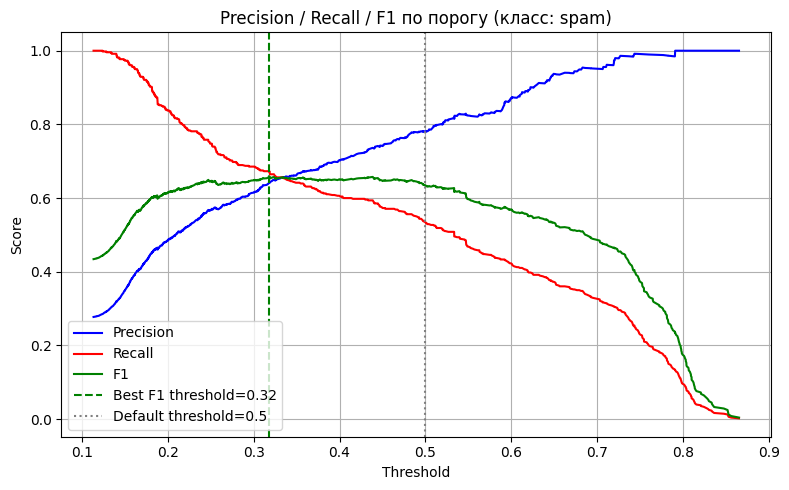

In [ ]:
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from sklearn.metrics import precision_recall_curve  # noqa: E402


labels_arr = np.array(all_labels)
probs_arr = np.array(all_probs)

precision, recall, thresholds = precision_recall_curve(labels_arr, probs_arr)

# F1 для каждого порога
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Оптимальный порог: {best_threshold:.3f}")
print(f"F1 при этом пороге: {best_f1:.3f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall:    {recall[best_idx]:.3f}")

# Для спама важнее recall — ищем порог с recall >= 0.90
high_recall_idx = np.where(recall[:-1] >= 0.90)[0]
if len(high_recall_idx) > 0:
    # Из них берём с максимальной precision
    best_recall_idx = high_recall_idx[precision[high_recall_idx].argmax()]
    print(f"\nПорог для recall >= 0.90: {thresholds[best_recall_idx]:.3f}")
    print(f"  Precision при этом: {precision[best_recall_idx]:.3f}")
    print(f"  → Обнови cfg.inference.threshold = {thresholds[best_recall_idx]:.3f}")

# График
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision", color="blue")
plt.plot(thresholds, recall[:-1], label="Recall", color="red")
plt.plot(thresholds, f1_scores, label="F1", color="green")
plt.axvline(best_threshold, color="green", linestyle="--",
            label=f"Best F1 threshold={best_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold=0.5")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 по порогу (класс: spam)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()